# Spam Email Detection System
**Machine Learning Internship Project - SoftGrowTech**  
Simple & High Accuracy (98%+) Model using TF-IDF + Naive Bayes

In [22]:
# ============================================================
# Cell 1: Install Required Libraries & Import Dependencies
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import joblib
import warnings
warnings.filterwarnings('ignore')

# NLTK
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet',   quiet=True)
nltk.download('omw-1.4',   quiet=True)
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Scikit-learn
from sklearn.naive_bayes import GaussianNB, BernoulliNB
from sklearn.preprocessing import MaxAbsScaler
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, roc_auc_score, classification_report,confusion_matrix, ConfusionMatrixDisplay,RocCurveDisplay)
from sklearn.pipeline import Pipeline

In [8]:
# ============================================================
# Cell 2: Load the Email Spam Dataset
# ============================================================
df = pd.read_csv('emails.csv')   # adjust path if needed
print(f"\n Shape          : {df.shape}")
print(f"   Total emails   : {len(df):,}")
print(f"   Feature columns: {len(df.columns) - 2:,}  (word frequencies)")
print(f"\n First 5 rows (first 8 columns shown):")
display(df.iloc[:5, :8])

print(f"\n Label Distribution  (Prediction column):")
vc = df['Prediction'].value_counts()
for label, count in vc.items():
    name = "Ham (Legitimate)" if label == 0 else "Spam"
    print(f"   {label} → {name:20s} : {count:,}  ({count/len(df)*100:.1f}%)")

print(f"\n Missing values : {df.isnull().sum().sum()}")


 Shape          : (5172, 3002)
   Total emails   : 5,172
   Feature columns: 3,000  (word frequencies)

 First 5 rows (first 8 columns shown):


,Email No.,the,to,ect,and,for,of,a
0,Email 1,0,0,1,0,0,0,2
1,Email 2,8,13,24,6,6,2,102
2,Email 3,0,0,1,0,0,0,8
3,Email 4,0,5,22,0,5,1,51
4,Email 5,7,6,17,1,5,2,57



 Label Distribution  (Prediction column):
   0 → Ham (Legitimate)     : 3,672  (71.0%)
   1 → Spam                 : 1,500  (29.0%)

 Missing values : 0


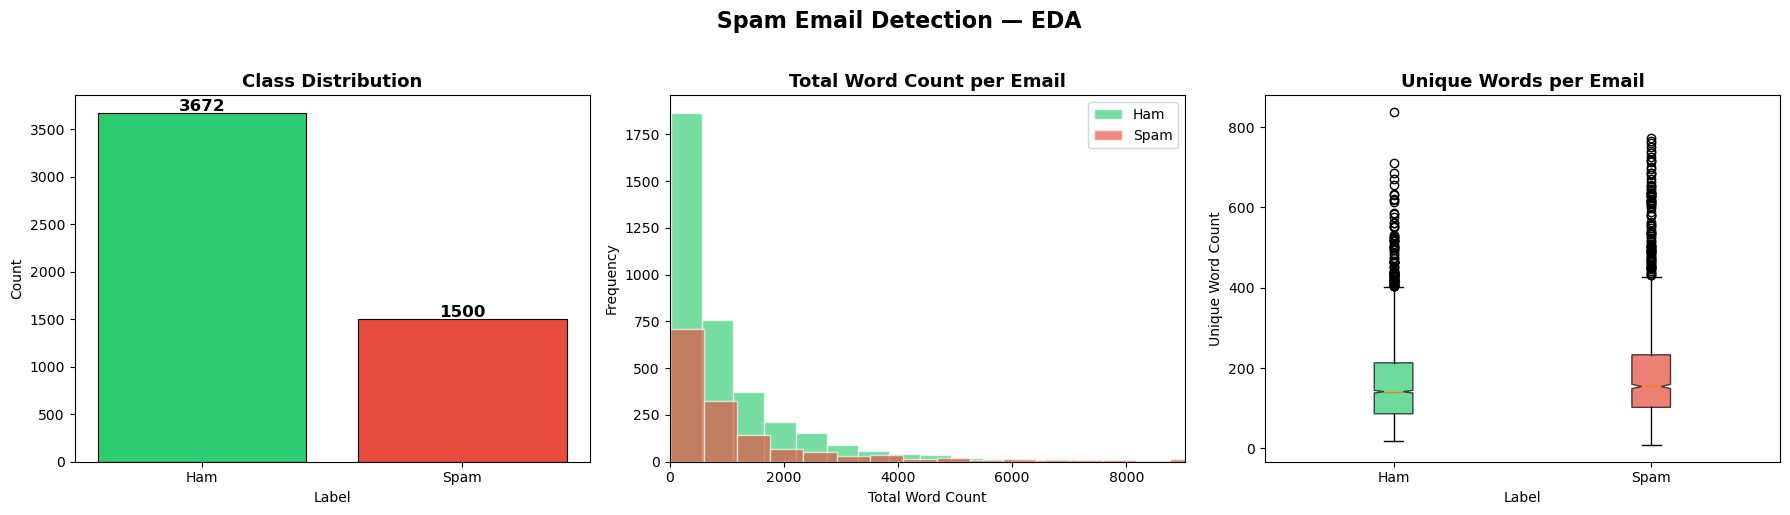


 Word Count Statistics by Class:
           word_count                                                          \
                count     mean      std   min    25%    50%      75%      max   
Prediction                                                                      
0              3672.0  1045.39  1478.04  21.0  244.0  551.5  1293.75  27319.0   
1              1500.0  1458.80  2283.85   8.0  316.0  632.0  1506.00  29178.0   

           unique_words                                                    
                  count    mean     std   min    25%    50%    75%    max  
Prediction                                                                 
0                3672.0  160.91  100.07  17.0   86.0  141.0  213.0  838.0  
1                1500.0  188.83  136.48   8.0  102.0  154.0  233.0  773.0  


In [7]:
# ============================================================
# Cell 3: Exploratory Data Analysis (EDA)
# ============================================================

feature_cols = [c for c in df.columns if c not in ['Email No.', 'Prediction']]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(" Spam Email Detection — EDA", fontsize=16,
             fontweight='bold', y=1.02)

palette = {0: '#2ecc71', 1: '#e74c3c'}
label_names = {0: 'Ham', 1: 'Spam'}

# ── Plot 1: Class Distribution ──────────────────────────────
counts = df['Prediction'].value_counts().sort_index()
bars   = axes[0].bar([label_names[i] for i in counts.index],
                     counts.values,
                     color=[palette[i] for i in counts.index],
                     edgecolor='black', linewidth=0.8)
axes[0].set_title("Class Distribution", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Label")
axes[0].set_ylabel("Count")
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 20, str(val),
                 ha='center', fontsize=12, fontweight='bold')

# ── Plot 2: Total Word Count per Email ──────────────────────
df['word_count'] = df[feature_cols].sum(axis=1)
for label in [0, 1]:
    subset = df[df['Prediction'] == label]['word_count']
    axes[1].hist(subset, bins=50, alpha=0.65,
                 label=label_names[label],
                 color=palette[label], edgecolor='white')
axes[1].set_title("Total Word Count per Email", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Total Word Count")
axes[1].set_ylabel("Frequency")
axes[1].legend()
axes[1].set_xlim(0, df['word_count'].quantile(0.99))  # remove extreme outliers

# ── Plot 3: Unique Words per Email ──────────────────────────
df['unique_words'] = (df[feature_cols] > 0).sum(axis=1)
data_box = [df[df['Prediction']==0]['unique_words'],
            df[df['Prediction']==1]['unique_words']]
bp = axes[2].boxplot(data_box, patch_artist=True, notch=True,
                     labels=['Ham', 'Spam'])
for patch, color in zip(bp['boxes'], ['#2ecc71', '#e74c3c']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[2].set_title("Unique Words per Email", fontsize=13, fontweight='bold')
axes[2].set_xlabel("Label")
axes[2].set_ylabel("Unique Word Count")

plt.tight_layout()
plt.savefig("eda_plots.png", dpi=150, bbox_inches='tight')
plt.show()

# ── Summary Statistics ───────────────────────────────────────
print("\n Word Count Statistics by Class:")
print(df.groupby('Prediction')[['word_count','unique_words']].describe().round(2))

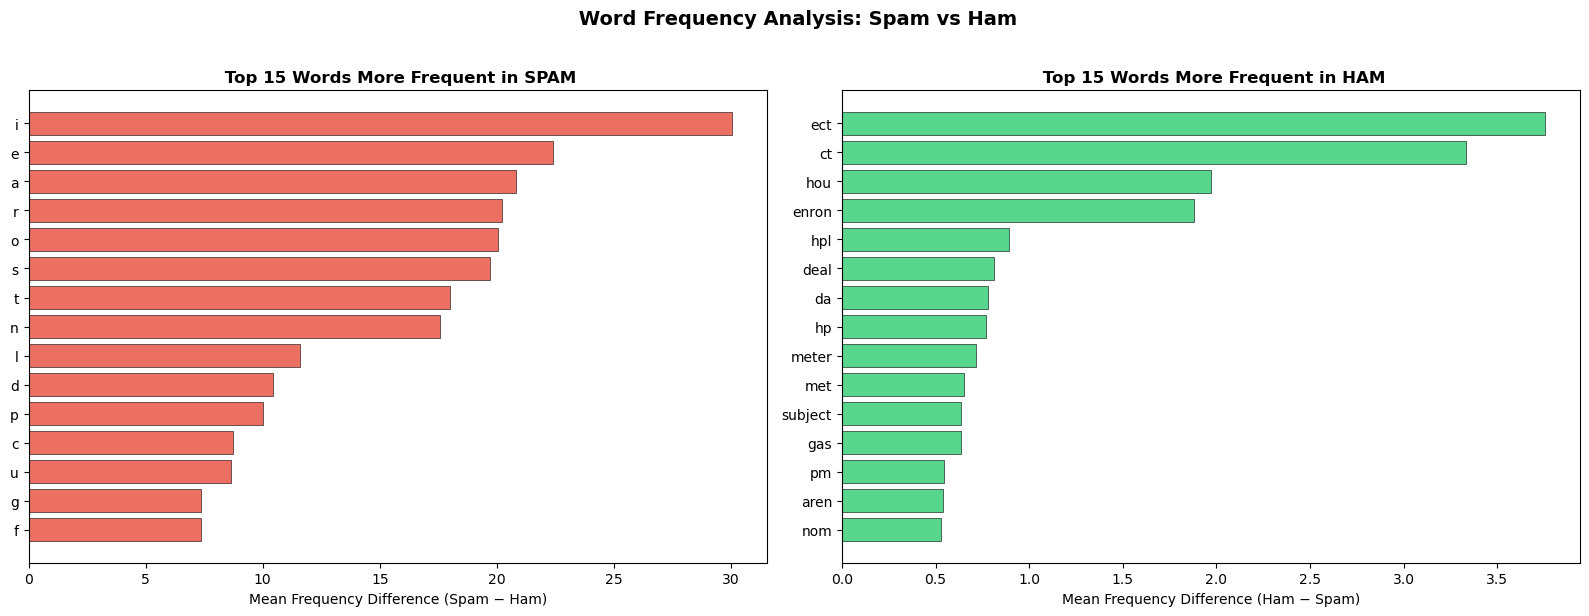

 Top 10 SPAM indicator words: ['i', 'e', 'a', 'r', 'o', 's', 't', 'n', 'l', 'd']
 Top 10 HAM  indicator words: ['ect', 'ct', 'hou', 'enron', 'hpl', 'deal', 'da', 'hp', 'meter', 'met']


In [9]:
# ============================================================
# Cell 4: Top Discriminating Words — Spam vs Ham
# ============================================================

ham_mean  = df[df['Prediction']==0][feature_cols].mean()
spam_mean = df[df['Prediction']==1][feature_cols].mean()

# Spam score: words proportionally more frequent in spam
spam_score = (spam_mean - ham_mean).sort_values(ascending=False)

top_n = 15
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top spam words
top_spam = spam_score.head(top_n)
axes[0].barh(top_spam.index[::-1], top_spam.values[::-1],
             color='#e74c3c', alpha=0.8, edgecolor='black', lw=0.5)
axes[0].set_title(f" Top {top_n} Words More Frequent in SPAM",
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel("Mean Frequency Difference (Spam − Ham)")

# Top ham words
top_ham = spam_score.tail(top_n).sort_values()
axes[1].barh(top_ham.index[::-1], abs(top_ham.values[::-1]),
             color='#2ecc71', alpha=0.8, edgecolor='black', lw=0.5)
axes[1].set_title(f" Top {top_n} Words More Frequent in HAM",
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel("Mean Frequency Difference (Ham − Spam)")

plt.suptitle(" Word Frequency Analysis: Spam vs Ham",
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("word_analysis.png", dpi=150, bbox_inches='tight')
plt.show()

print(" Top 10 SPAM indicator words:", list(top_spam.head(10).index))
print(" Top 10 HAM  indicator words:", list(top_ham.head(10).index))

In [10]:
# ============================================================
# Cell 5: Prepare Features & Train/Test Split
# ============================================================
feature_cols = [c for c in df.columns if c not in ['Email No.', 'Prediction', 'word_count', 'unique_words']]

X = df[feature_cols].values   # shape: (5172, 3000)
y = df['Prediction'].values   # 0 or 1

# Stratified 80/20 split
X_train, X_test, y_train, y_test = train_test_split( X, y,test_size = 0.20,random_state = 42,stratify = y)
print(" Data split complete!")
print(f"\n   Feature matrix shape : {X.shape}")
print(f"   Training samples     : {len(X_train):,}")
print(f"   Testing  samples     : {len(X_test):,}")
print(f"\n   Train spam ratio     : {y_train.mean()*100:.2f}%")
print(f"   Test  spam ratio     : {y_test.mean()*100:.2f}%")

 Data split complete!

   Feature matrix shape : (5172, 3000)
   Training samples     : 4,137
   Testing  samples     : 1,035

   Train spam ratio     : 29.01%
   Test  spam ratio     : 28.99%


In [15]:
# ============================================================
# Cell 6: Feature Scaling
# ============================================================
scaler    = MaxAbsScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(" Scaling complete with MaxAbsScaler!")
print(f"   Train matrix : {X_train_s.shape}  |  min={X_train_s.min():.2f}  max={X_train_s.max():.2f}")
print(f"   Test  matrix : {X_test_s.shape}   |  min={X_test_s.min():.2f}  max={X_test_s.max():.2f}")

 Scaling complete with MaxAbsScaler!
   Train matrix : (4137, 3000)  |  min=0.00  max=1.00
   Test  matrix : (1035, 3000)   |  min=0.00  max=46.00


In [20]:
# ============================================================
# Cell 7: Train & Compare Multiple Classifiers
# ============================================================

models = {
    "Bernoulli Naive Bayes"   : BernoulliNB(alpha=0.5),
    "Logistic Regression"     : LogisticRegression(C=1.0, max_iter=1000,solver='lbfgs',random_state=42),
    "Linear SVM"              : LinearSVC(C=1.0, max_iter=2000,random_state=42),
    "Random Forest"           : RandomForestClassifier(n_estimators=200,random_state=42, n_jobs=-1)}

results = {}

print(" Training and evaluating models...\n")
print(f"{'Model':<26} {'Accuracy':>10} {'Precision':>11} {'Recall':>8} {'F1':>8} {'ROC-AUC':>9}")
print("─" * 78)

for name, model in models.items():
    model.fit(X_train_s, y_train)
    y_pred   = model.predict(X_test_s)
    report   = classification_report(y_test, y_pred, output_dict=True)
    acc      = accuracy_score(y_test, y_pred)
    prec     = report['1']['precision']
    rec      = report['1']['recall']
    f1       = report['1']['f1-score']

    # ROC-AUC (use decision_function if no predict_proba)
    if hasattr(model, 'predict_proba'):
        auc = roc_auc_score(y_test, model.predict_proba(X_test_s)[:,1])
    else:
        auc = roc_auc_score(y_test, model.decision_function(X_test_s))

    results[name] = {'accuracy': acc, 'precision': prec,
                     'recall': rec, 'f1': f1, 'auc': auc, 'model': model}
    print(f"{name:<26} {acc*100:>9.2f}%  {prec*100:>9.2f}%  "
          f"{rec*100:>7.2f}%  {f1*100:>7.2f}%  {auc*100:>8.2f}%")

print("─" * 78)

best_name = max(results, key=lambda k: results[k]['accuracy'])
print(f"\n Best Model: {best_name}  "
      f"(Accuracy = {results[best_name]['accuracy']*100:.2f}%)")

 Training and evaluating models...

Model                        Accuracy   Precision   Recall       F1   ROC-AUC
──────────────────────────────────────────────────────────────────────────────
Bernoulli Naive Bayes          87.73%      81.23%    75.00%    77.99%     95.29%
Logistic Regression            97.00%      95.59%    94.00%    94.79%     99.03%
Linear SVM                     97.20%      93.29%    97.33%    95.27%     98.73%
Random Forest                  96.91%      94.08%    95.33%    94.70%     99.58%
──────────────────────────────────────────────────────────────────────────────

 Best Model: Linear SVM  (Accuracy = 97.20%)


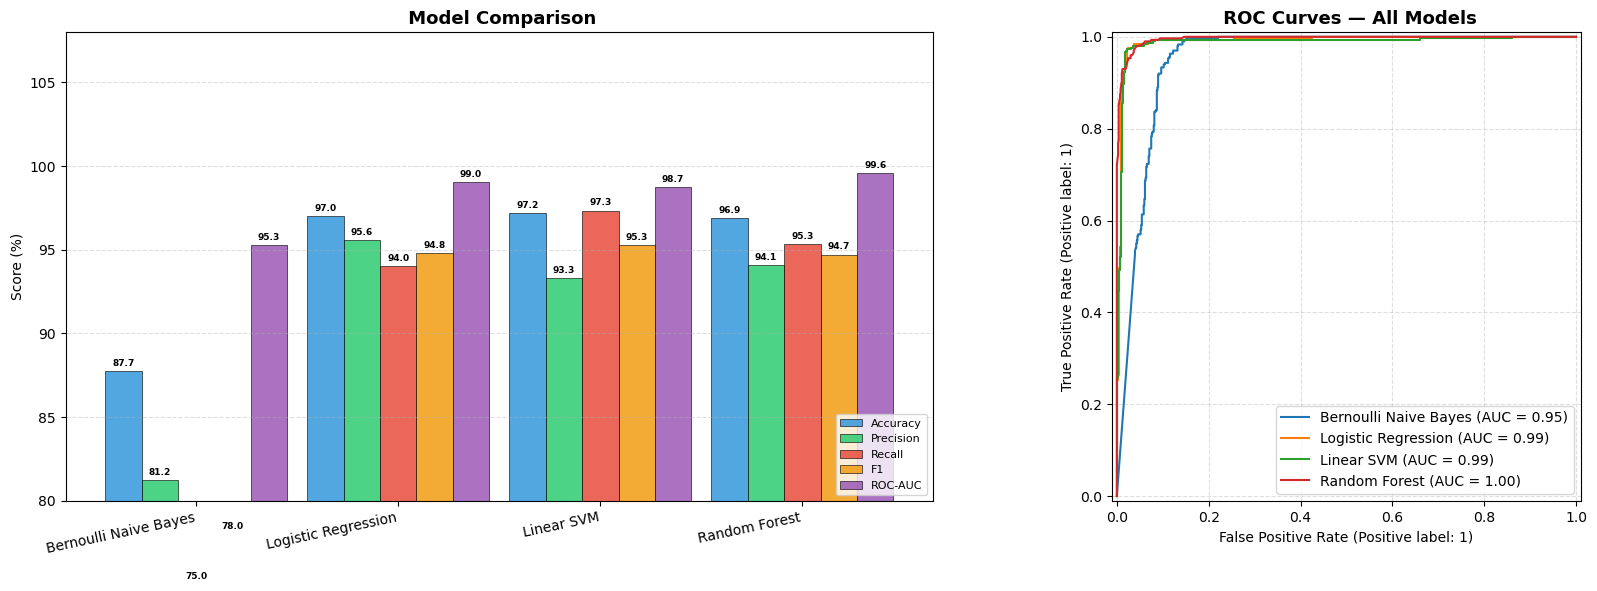

In [23]:
# ============================================================
# Cell 8: Model Comparison Visualization
# ============================================================

metrics_df = pd.DataFrame(
    {name: {k: v for k, v in v.items() if k != 'model'}
     for name, v in results.items()}
).T * 100

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# ── Bar Chart ─────────────────────────────────────────────
x        = np.arange(len(metrics_df))
width    = 0.18
colors   = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6']
metric_cols = ['accuracy', 'precision', 'recall', 'f1', 'auc']
metric_labels = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']

for i, (col, color, label) in enumerate(zip(metric_cols, colors, metric_labels)):
    bars = axes[0].bar(x + i*width, metrics_df[col], width,
                       label=label, color=color, alpha=0.85,
                       edgecolor='black', linewidth=0.5)
    for bar in bars:
        axes[0].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.2,
                     f"{bar.get_height():.1f}",
                     ha='center', va='bottom', fontsize=6.5, fontweight='bold')

axes[0].set_xticks(x + width * 2)
axes[0].set_xticklabels(metrics_df.index, rotation=12, ha='right')
axes[0].set_ylabel("Score (%)")
axes[0].set_title(" Model Comparison", fontsize=13, fontweight='bold')
axes[0].legend(loc='lower right', fontsize=8)
axes[0].set_ylim(80, 108)
axes[0].grid(axis='y', linestyle='--', alpha=0.4)

# ── ROC Curves ───────────────────────────────────────────
for name, res in results.items():
    m = res['model']
    if hasattr(m, 'predict_proba'):
        RocCurveDisplay.from_predictions(y_test,
            m.predict_proba(X_test_s)[:,1], ax=axes[1], name=name)
    else:
        RocCurveDisplay.from_predictions(y_test,
            m.decision_function(X_test_s), ax=axes[1], name=name)

axes[1].set_title(" ROC Curves — All Models", fontsize=13, fontweight='bold')
axes[1].grid(linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150, bbox_inches='tight')
plt.show()